# Econ 390 - Lecture 25: Least Absolute Shrinkage and Selection Operator (Lasso)
Today we'll be talking about Machine Learning, specifically the Lasso regression. You can find a chapter in [Turrell](https://aeturrell.github.io/coding-for-economists/ml-sup.html) that covers Lasso and other similar regression methods. I also used [this](https://geostatsguy.github.io/MachineLearningDemos_Book/MachineLearning_LASSO_regression.html) resource when creating this lecture. Machine Learning is a complicated topic, you can spend much much more time on Lasso alone. Regardless, I am hoping after this class you can have at least a basic understanding of how Lasso works and how it can be useful.

## The Lasso

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Reproducability
seed = 42
prng = np.random.default_rng(seed)

In [3]:
# New library!
from sklearn.datasets import make_regression

# Creates a dataset based on a randomized regression
X, y, coef = make_regression(n_samples=500, n_features=6, noise=0.5, random_state=seed, coef=True)

In [7]:
# What is X?
print(type(X))
print(X.shape)

<class 'numpy.ndarray'>
(500, 6)


In [9]:
# Convert to DataFrame
reg_df = pd.DataFrame(X)
reg_df["y"] = y
reg_df.head()

,0,1,2,3,4,5,y
0,-0.753965,0.281191,-0.062593,-0.280675,0.758929,0.104201,43.220530
1,1.031845,-0.439731,0.196555,-1.485560,-0.186872,1.446978,-9.556226
2,-0.600639,0.110923,0.375698,-0.291694,-0.544383,-1.150994,-62.911906
3,0.998311,-0.322320,1.521316,-0.431620,1.615376,1.217159,307.752538
4,0.338496,0.770865,1.143754,-0.415288,0.235615,-1.478586,167.728761


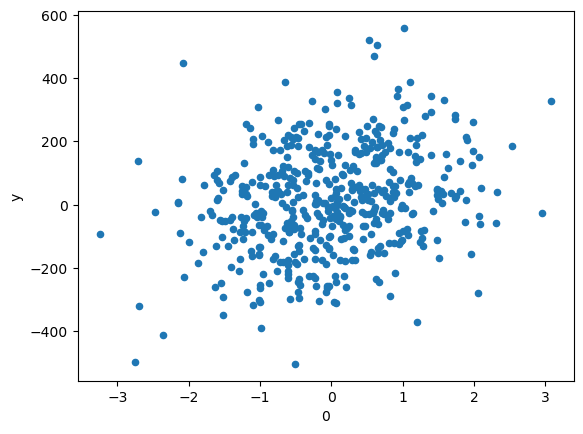

In [10]:
# x0 on y
reg_df.plot.scatter(x=0,y="y");

In [11]:
# Supervised means training set and test set
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(reg_df, random_state=seed, test_size=0.2)
train_df

,0,1,2,3,4,5,y
249,-1.116524,1.533728,-1.707358,1.235812,-0.629263,-0.535801,-85.096380
433,-2.123896,-0.808298,-0.599393,-0.525755,2.189803,-0.839722,-89.842998
19,1.117399,-0.548287,0.501783,1.448499,-0.155898,0.160018,85.391162
322,0.484733,1.281016,0.852774,-0.846357,-0.447322,0.067856,165.681418
332,-0.019260,-0.191028,0.784604,-0.262891,-2.562334,2.412615,-99.893249
...,...,...,...,...,...,...,...
106,1.059936,-0.862776,-0.392013,0.617006,-0.478837,0.693479,-76.958580
270,-0.742484,0.003696,1.341476,-0.485306,1.962587,1.011463,269.059898
348,1.083051,-1.142970,0.560785,1.053802,0.058209,0.357787,39.568143
435,-0.569833,0.287329,-0.424236,0.329509,-0.287448,-0.045512,-50.974463


In [12]:
# Let's run Lasso!
from sklearn import linear_model

reg_lasso = linear_model.Lasso(alpha=0.1, random_state=seed)
reg_lasso.fit(train_df.iloc[:,:-1],train_df["y"])

Lasso(alpha=0.1, random_state=42)

In [13]:
# Results:
reg_lasso.coef_

array([43.04444381, 98.23909293, 96.83389336, 34.68124549, 81.74516152,
       25.85780195])

In [15]:
# Predictions:
print(reg_lasso.predict(test_df.iloc[:5,:-1]))
test_df.head()

[ 163.08609994 -169.85887763  -66.33847724  -35.00337041 -262.31589457]


,0,1,2,3,4,5,y
361,0.414866,0.342338,0.853976,0.463289,-0.335138,1.554160,163.401193
73,-0.822220,-0.321386,-0.563725,0.243687,-0.825497,0.412931,-170.729725
374,0.014273,0.892597,0.730764,-0.953939,-1.970104,-1.211172,-67.471072
155,-0.170185,-0.551186,-0.003374,-0.453228,0.778361,-0.818199,-34.828869
104,-0.999302,-0.607822,-0.022868,-0.504775,-2.121855,1.296995,-262.404723


In [17]:
# Mean Square Error (MSE):
from sklearn.metrics import mean_squared_error

mean_squared_error(y_true=test_df["y"], y_pred=reg_lasso.predict(test_df.iloc[:,:-1]))

0.39654453453700406

In [18]:
# Compare MSE in and out of sample
mse_df = pd.DataFrame(index=["out-of-sample","in-sample"],columns=["Lasso"])
mse_df.loc["out-of-sample","Lasso"] = mean_squared_error(y_true=test_df["y"],y_pred=reg_lasso.predict(test_df.iloc[:,:-1]))
mse_df.loc["in-sample","Lasso"] = mean_squared_error(y_true=train_df["y"], y_pred = reg_lasso.predict(train_df.iloc[:,:-1]))
mse_df

,Lasso
out-of-sample,0.396545
in-sample,0.317716


In [19]:
# Prediction vs. Truth
results_df = pd.DataFrame()

results_df["prediction"] = reg_lasso.predict(test_df.iloc[:,:-1])
results_df["actual"] = test_df["y"].values

results_df.head()

,prediction,actual
0,163.086100,163.401193
1,-169.858878,-170.729725
2,-66.338477,-67.471072
3,-35.003370,-34.828869
4,-262.315895,-262.404723


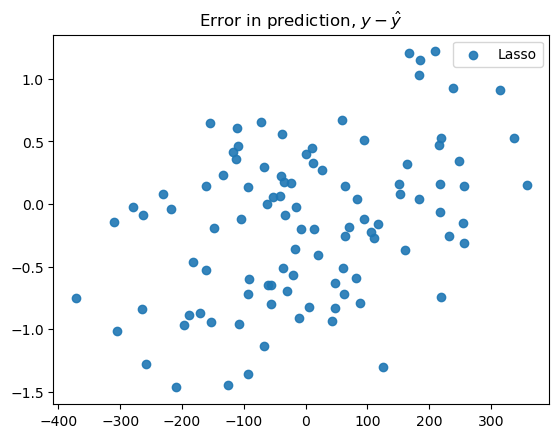

In [21]:
# Plot the errors
fig, ax = plt.subplots()

ax.scatter(results_df["actual"], results_df["actual"]-results_df["prediction"], alpha=0.9, label = "Lasso")
ax.legend()
ax.set_title(r"Error in prediction, $y -\hat{y}$")
plt.show()

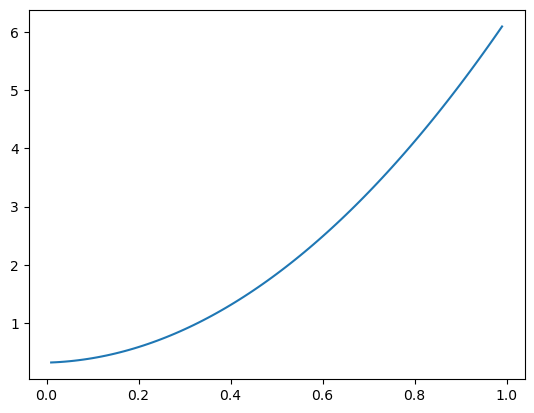

In [23]:
# Different values of alpha
mse_all = []
alpha_all = []
for i in range(1, 100, 1):
    reg_lasso = linear_model.Lasso(alpha=i/100, random_state=seed)
    reg_lasso.fit(train_df.iloc[:,:-1],train_df["y"])
    mse = mean_squared_error(y_true=test_df["y"],y_pred=reg_lasso.predict(test_df.iloc[:,:-1]))
    mse_all = mse_all + [mse]
    alpha_all = alpha_all + [i/100]
plt.plot(alpha_all, mse_all);

## UCI Machine Learning Repository
UC Irvine has a [website](https://archive.ics.uci.edu/) full of datasets that are useful for Machine Learning! Today we will be using the [Default of Credit Cards](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients) dataset.

In [24]:
econ390path = "https://m-mcmain.github.io/files/Econ390SP26/"

In [26]:
# Read in the data
default = pd.read_csv(econ390path + "default_of_credit_card_clients_cut.csv")
log_columns = ["LIMIT_BAL", "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6", 
               "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]
default[log_columns] = np.arcsinh(default[log_columns])
default

,LIMIT_BAL,SEX,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,10.596635,2,24,8.965207,8.732950,7.228389,0.000000,0.000000,0.000000,0.000000,7.228389,0.000000,0.000000,0.000000,0.000000,1
1,12.388394,2,26,8.587465,8.146130,8.587465,8.786304,8.840725,8.782936,0.000000,7.600903,7.600903,7.600903,0.000000,8.294050,1
2,12.100712,2,34,10.976406,10.241887,10.207953,10.263327,10.305480,10.344899,8.018296,8.006368,7.600903,7.600903,7.600903,9.210340,0
3,11.512925,2,37,11.450837,11.476946,11.498644,10.944259,10.966783,10.986885,8.294050,8.303505,7.783224,7.696213,7.667626,7.600903,0
4,11.512925,1,57,9.754639,9.336092,11.179828,10.642564,10.552996,10.552213,8.294050,11.203161,9.903488,9.798127,7.228389,7.213769,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,12.994530,1,39,12.842374,12.862634,12.940194,12.078285,11.042506,10.372240,9.740969,10.596635,9.210940,8.715060,9.210340,7.600903,0
29996,12.611538,1,43,8.121480,8.204125,8.854237,9.795791,9.247636,0.000000,8.209036,8.861067,9.797905,5.552975,0.000000,0.000000,0
29997,11.002100,1,37,8.872067,8.811652,8.615408,10.639598,10.625319,10.563957,0.000000,0.000000,10.691945,9.035987,8.294050,8.732305,1
29998,11.982929,1,41,-8.098643,11.962458,11.935628,11.566921,10.073652,11.491579,12.054086,8.827321,7.764721,8.256348,11.570515,8.190909,1


In [28]:
# Create the training and testing set
train_default, test_default = train_test_split(default, random_state=seed, test_size = 0.2)
train_default.rename(columns={"default payment next month":"default"}, inplace=True)
train_default

,LIMIT_BAL,SEX,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
21753,11.982929,2,24,11.920056,11.949282,11.961718,11.901326,11.280817,11.276114,8.854522,9.210540,8.339023,7.798113,7.969012,7.470794,0
251,11.002100,1,28,10.976508,10.985530,10.973529,10.829927,10.691990,0.000000,9.211540,7.819235,7.439560,7.554859,0.000000,0.000000,0
22941,12.793859,2,44,10.641417,0.000000,7.438384,0.000000,9.529666,9.936922,0.000000,7.438384,0.000000,9.529666,9.936922,5.897161,0
618,11.695247,1,25,11.675707,11.575619,11.252417,11.280716,11.280211,11.268047,8.303009,8.242756,8.294050,8.006368,8.242756,8.294050,0
17090,12.468437,2,25,12.315707,12.322504,12.343519,12.370086,12.395486,12.420410,9.011889,9.035987,9.210340,9.210340,9.210340,9.971146,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29802,11.512925,1,32,11.561239,11.582452,11.621583,11.625486,10.976372,9.412301,8.294050,8.699515,8.065265,4.969862,7.726654,11.897112,0
5390,12.899220,1,37,12.657982,12.716438,12.727161,12.701878,12.730973,12.748885,10.203592,9.392662,0.000000,9.615805,9.392662,8.987197,1
860,11.512925,1,26,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
15795,11.849398,2,25,11.904143,11.856345,11.535704,11.159730,10.955462,10.934499,8.699515,8.294050,9.104980,7.783224,0.000000,7.783224,1


In [31]:
# Standard OLS
import statsmodels.formula.api as smf
all_columns = "+".join(train_default.columns[:-1])
formula = "default ~ "+all_columns
print(smf.ols(formula, data=train_default).fit().summary())

                            OLS Regression Results                            
Dep. Variable:                default   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.104
Method:                 Least Squares   F-statistic:                     187.7
Date:                Tue, 28 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:18:48   Log-Likelihood:                -11641.
No. Observations:               24000   AIC:                         2.331e+04
Df Residuals:                   23984   BIC:                         2.344e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.8012      0.038     21.365      0.0

In [32]:
# Collect the results for many different alpha
alpha_all = []
coef_all = []
for i in range(1,100,1):
    reg_lasso = linear_model.Lasso(alpha=i/100, random_state=seed)
    reg_lasso.fit(train_default.iloc[:,:-1], train_default.iloc[:,-1])
    coef = reg_lasso.coef_
    coef_all = coef_all + [coef]
    alpha_all = alpha_all + [i/100]

In [20]:
# Plot the MSE over alpha


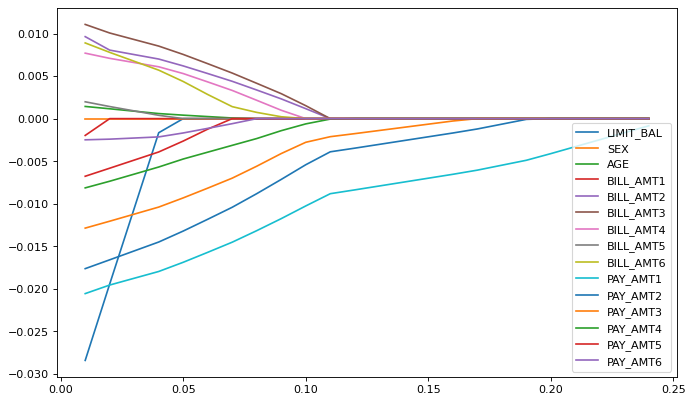

In [34]:
# Plot the coefficients for different values of alpha, natural Feature Selection
plt.figure(figsize=(10,6),dpi=80)
plt.plot(alpha_all[:24], coef_all[:24], label=test_default.columns[:-1])
plt.legend();

## Optional Extra Credit Posted
You've likely noticed the new "assignment" on Canvas. It is a completely optional extra credit that will cover the Lasso and is worth 5 Assignment points. These points will be added on *after* the curve is applied. So, importantly, not doing this extra credit will have **no negative impact** on your grade. This is just a way to give people who are right on the edge of a grade cutoff to get that little boost necessary to get "bumped" up. 

Here's the calculation:
1. I will do the standard curve, splitting up the class into bins based on percentiles.
   - This will set the grade cutoffs for each letter
2. I will then add any extra credit after the cutoffs are set
   - If the extra credit pushes you above the cutoff, your letter grade will go up
3. I will then compare that grade to the grade your numerical score would earn and choose the higher of the two

## End of Content
We made it! Before we leave, I'd appreciate if you could take 5-10 minutes here completing the [course evaluation](https://heliocampusac.wisc.edu/) if you haven't already. You should be able to click on the link, login, and look for the "Available Forms" tile and click on this course. 

Since this is my first time as an instructor and first time teaching this course, you can have a very big impact on what this course looks like if I teach it again. So I would appreciate any honest, constructive feedback you have for me!

Thanks for spending part of your semester with me in Econ 390 and on Thursday we will review for the Final Exam.